In [5]:
import pandas as pd
import numpy as np

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("customer_segmentation.csv")
df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [8]:
df.columns


Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [9]:
df.shape

(2240, 29)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [11]:
df.isna().sum().sum() #Number of null values

24

In [12]:
df = df.dropna() #Drop null values 

In [13]:
df.isna().sum().sum() #Number of null values after dropping

0

In [14]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000
mean,5588.353339,1968.820397,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,...,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271
std,3249.376275,11.985554,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,...,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [15]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst = True) #Changinf the type of data of date time object

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2216 non-null   int64         
 1   Year_Birth           2216 non-null   int64         
 2   Education            2216 non-null   object        
 3   Marital_Status       2216 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2216 non-null   int64         
 6   Teenhome             2216 non-null   int64         
 7   Dt_Customer          2216 non-null   datetime64[ns]
 8   Recency              2216 non-null   int64         
 9   MntWines             2216 non-null   int64         
 10  MntFruits            2216 non-null   int64         
 11  MntMeatProducts      2216 non-null   int64         
 12  MntFishProducts      2216 non-null   int64         
 13  MntSweetProducts     2216 non-null   i

In [17]:
spend_cols = ['MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds']

In [18]:
df["Total_Spending"] = df[spend_cols].sum(axis = 1)

In [19]:
df["Total_Spending"]

0       1617
1         27
2        776
3         53
4        422
        ... 
2235    1341
2236     444
2237    1241
2238     843
2239     172
Name: Total_Spending, Length: 2216, dtype: int64

In [20]:
df["Customer_Since"] = (pd.Timestamp("today") - df["Dt_Customer"]).dt.days

In [21]:
df["Customer_Since"]

0       5065
1       4515
2       4714
3       4541
4       4563
        ... 
2235    4783
2236    4421
2237    4557
2238    4558
2239    5024
Name: Customer_Since, Length: 2216, dtype: int64

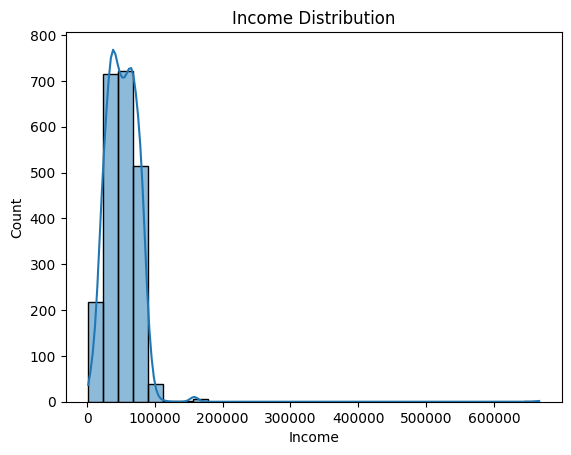

In [22]:
#Exploratory data analysis
#Income distribution
sns.histplot(df["Income"], bins = 30, kde = True)
plt.title("Income Distribution")
plt.show()

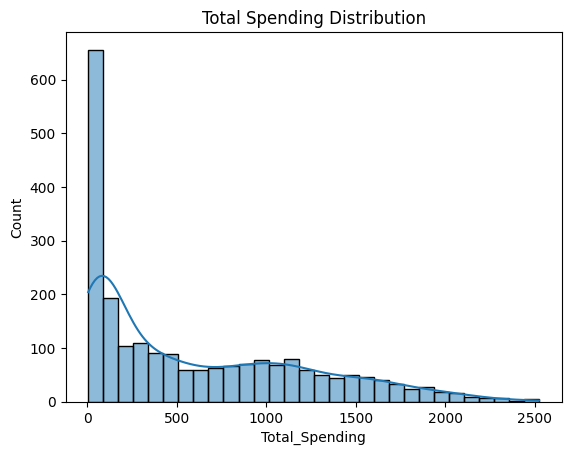

In [23]:
#Spending distribution
sns.histplot(df["Total_Spending"], bins = 30, kde = True)
plt.title("Total Spending Distribution")
plt.show()

In [24]:
NumberofPurchases = ['NumDealsPurchases', 'NumWebPurchases','NumCatalogPurchases', 'NumStorePurchases']

In [25]:
df["Frequency"] = df[NumberofPurchases].sum(axis = 1)

In [26]:
features = ["Total_Spending", "Recency", "Frequency"]

In [27]:
X = df[features].copy()

In [28]:
X

,Total_Spending,Recency,Frequency
0,1617,58,25
1,27,38,6
2,776,26,21
3,53,26,8
4,422,94,19
...,...,...,...
2235,1341,46,18
2236,444,56,22
2237,1241,91,19
2238,843,8,23


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [30]:
X_scaled = scaler.fit_transform(X)

In [31]:
#Determine optimal number of clusters - Elbow method
from sklearn.cluster import KMeans

In [32]:
WCSS = []

In [36]:
for i in range(2,10): 
    kmeans = KMeans(n_clusters = i)
    kmeans.fit(X_scaled)
    WCSS.append(kmeans.inertia_)

/home/reva/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/reva/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/reva/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/reva/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set 

In [37]:
WCSS

[3543.6169025897775,
 2590.265268565116,
 1885.7735212962084,
 1590.830243892306,
 1377.958453156736,
 1225.851655765509,
 1085.9870735954287,
 987.944537053188]

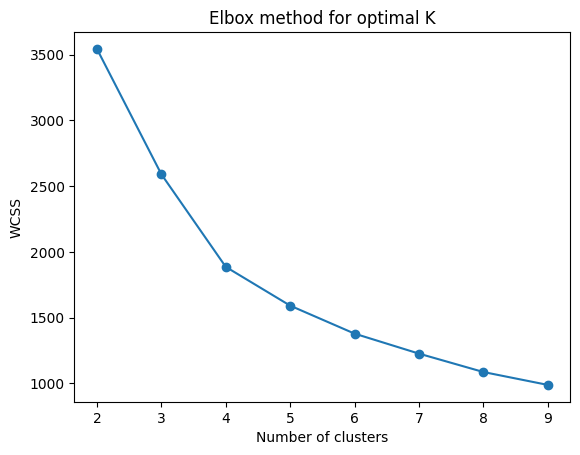

In [38]:
plt.plot(range(2,10), WCSS, marker = "o")
plt.title("Elbox method for optimal K")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

In [39]:
kmeans = KMeans(n_clusters = 4)
df["Cluster"] = kmeans.fit_predict(X_scaled)

/home/reva/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [43]:
cluster_summary = df.groupby("Cluster")[features].mean()

In [ ]:
cluster_summary
#Total spending --> M average amount spent by customer in the cluster
#Recency --> R How many days back on an averga ehad a customer ordered
#Frequenncy --> F how many times on an average did the cluster order

,Total_Spending,Recency,Frequency
Cluster,,,
0,129.219634,24.469218,8.673877
1,1148.059041,72.970480,21.511070
2,1133.473054,23.133733,21.904192
3,135.489510,74.765734,8.968531


In [51]:
def func(row):
    if row["Cluster"] == 0:
        return 'Average Customers'
    elif row["Cluster"] == 1:
        return 'Loyal Customers'
    elif row['Cluster'] == 2:
        return 'VIP Customers'
    else:
        return 'Inactive Customers'
    

In [52]:
df["Conditions"] = df.apply(func, axis=1)

In [54]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Total_Spending,Customer_Since,Frequency,Cluster,Conditions
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,3,11,1,1617,5065,25,1,Loyal Customers
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,3,11,0,27,4515,6,0,Average Customers
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,3,11,0,776,4714,21,2,VIP Customers
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,3,11,0,53,4541,8,0,Average Customers
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,3,11,0,422,4563,19,1,Loyal Customers


In [ ]:
#print with RFM cluster name and class and customer id

In [56]:
result = df['Conditions'].value_counts()

In [57]:
result

Conditions
Average Customers     601
Inactive Customers    572
Loyal Customers       542
VIP Customers         501
Name: count, dtype: int64